In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp
import random
import tensorflow as tf

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Load Dataset

In [114]:
pose_vector = pd.read_csv("output/pose.csv")
y = pose_vector.pop('Pose_Class').to_numpy()
y = [int(val.replace('P', '')) - 1 for val in y]
print(y)
points = pose_vector.to_numpy()

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

### Reshape to body parts (instead of individual coordinates)

In [115]:
pose_vector = points.reshape((-1, 33, 4))
pose_vector.shape

(4467, 33, 4)

### List of joint connections

In [116]:
mp_pose = mp.solutions.pose
connections = mp_pose.POSE_CONNECTIONS
print(list(connections))

connections_array = np.array(list(connections)).T
print(connections_array)
print(connections_array.shape)

[(15, 21), (16, 20), (18, 20), (3, 7), (14, 16), (23, 25), (28, 30), (11, 23), (27, 31), (6, 8), (15, 17), (24, 26), (16, 22), (4, 5), (5, 6), (29, 31), (12, 24), (23, 24), (0, 1), (9, 10), (1, 2), (0, 4), (11, 13), (30, 32), (28, 32), (15, 19), (16, 18), (25, 27), (26, 28), (12, 14), (17, 19), (2, 3), (11, 12), (27, 29), (13, 15)]
[[15 16 18  3 14 23 28 11 27  6 15 24 16  4  5 29 12 23  0  9  1  0 11 30
  28 15 16 25 26 12 17  2 11 27 13]
 [21 20 20  7 16 25 30 23 31  8 17 26 22  5  6 31 24 24  1 10  2  4 13 32
  32 19 18 27 28 14 19  3 12 29 15]]
(2, 35)


### Visualise Skeleton

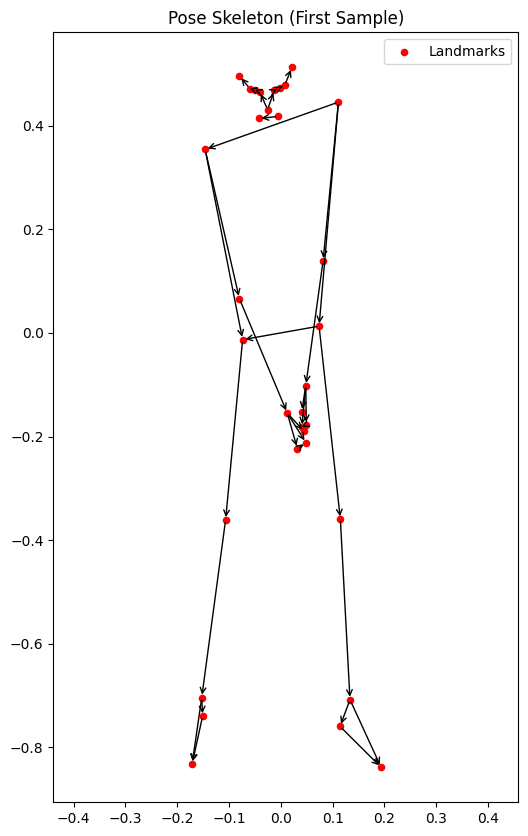

In [117]:
from matplotlib.patches import FancyArrowPatch

sample = pose_vector[0]

plt.figure(figsize=(6, 10))
plt.scatter(sample[:, 0], -sample[:, 1], c='red', s=20, label='Landmarks')

ax = plt.gca()
for start, end in connections:
    x_start, y_start = sample[start, 0], -sample[start, 1]
    x_end, y_end = sample[end, 0], -sample[end, 1]
    arrow = FancyArrowPatch((x_start, y_start), (x_end, y_end),
                            arrowstyle='->', color='k', mutation_scale=10, linewidth=1)
    ax.add_patch(arrow)

plt.title("Pose Skeleton (First Sample)")
plt.axis('equal')
plt.legend()
plt.show()

In [118]:
pip install torch torch-geometric

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [119]:
import torch
from torch_geometric.data import Data, Dataset
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

### Custom Pose Dataset for Graph

In [ ]:
class PoseDataset(Dataset):
    def __init__(self, pose_data, labels, edge_index):
        super().__init__()
        self.pose_data = pose_data  # shape: [num_samples, 33, 4] - 33 keypoints with 4d features
        self.labels = labels        # shape: [num_samples] 
        self.edge_index = edge_index  # shape: [2, num_edges] - edges that define graph structure

    def __len__(self):
        return len(self.pose_data) # total num of samples

    def __getitem__(self, idx):
        x = torch.tensor(self.pose_data[idx], dtype=torch.float)  # one sample's features [33, 4]
        y = torch.tensor(self.labels[idx], dtype=torch.long) # label
        return Data(x=x, edge_index=self.edge_index, y=y)

### GNN Model

In [ ]:
class GNNModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64, output_dim=10):  # output_dim = num classes
        super(GNNModel, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim) # first layer
        self.conv2 = GCNConv(hidden_dim, hidden_dim) # second layer
        self.fc = nn.Linear(hidden_dim, output_dim) # final classifier

def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch  # x: [N, 4]

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)

        x = global_mean_pool(x, batch)  # shape: [batch_size, hidden_dim]
        x = self.fc(x)
        return x


### Split data into train, val, test sets

In [130]:
def split_gnn_dataset(pose_vector, labels, edge_index, test_size=0.2, random_state=0):
    # split test set
    points_trainval, points_test, y_trainval, y_test = train_test_split(
        pose_vector, labels, test_size=test_size, random_state=random_state, stratify=labels
    )

    # split train and val set
    points_train, points_val, y_train, y_val = train_test_split(
        points_trainval, y_trainval, test_size=test_size, random_state=random_state, stratify=y_trainval
    )

    print(f"Train: {len(points_train)}, Val: {len(points_val)}, Test: {len(points_test)}")

    def to_dataset(points, y):
        return PoseDataset(points, y, edge_index)

    return to_dataset(points_train, y_train), to_dataset(points_val, y_val), to_dataset(points_test, y_test)


### Prepare datasets and dataloaders

In [131]:
edge_index = torch.tensor(connections_array, dtype=torch.long)  # convert to LongTensor
dataset = PoseDataset(pose_vector, y, edge_index)

# x=pose_vector, y is label array (0 to 9), edge_index is from body connections
train_dataset, val_dataset, test_dataset = split_gnn_dataset(pose_vector, y, edge_index, test_size=0.3)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

Train: 2188, Val: 938, Test: 1341


### Init model and params

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNNModel(input_dim=4, hidden_dim=64, output_dim=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

### Evaluation Function

In [ ]:
def evaluate(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0
    with torch.no_grad():
        for data in dataloader:
            data = data.to(device)
            out = model(data)
            loss = loss_fn(out, data.y)
            total_loss += loss.item() * data.num_graphs
            pred = out.argmax(dim=1)
            correct += (pred == data.y).sum().item()
            total += data.num_graphs
    return total_loss / total, correct / total

### Training Loop with Validation

In [ ]:
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(1, 501):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = loss_fn(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs

    train_loss = total_loss / len(train_loader.dataset)
    val_loss, val_acc = evaluate(model, val_loader, device)

    # Store values
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch:02d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 01, Train Loss: 2.1942, Val Loss: 2.0654, Val Acc: 0.2441
Epoch 02, Train Loss: 1.9865, Val Loss: 1.9430, Val Acc: 0.2942
Epoch 03, Train Loss: 1.9155, Val Loss: 1.8962, Val Acc: 0.3731
Epoch 04, Train Loss: 1.8773, Val Loss: 1.8648, Val Acc: 0.3497
Epoch 05, Train Loss: 1.8443, Val Loss: 1.8242, Val Acc: 0.3806
Epoch 06, Train Loss: 1.8154, Val Loss: 1.7929, Val Acc: 0.3721
Epoch 07, Train Loss: 1.7790, Val Loss: 1.7571, Val Acc: 0.4009
Epoch 08, Train Loss: 1.7481, Val Loss: 1.7315, Val Acc: 0.4126
Epoch 09, Train Loss: 1.7197, Val Loss: 1.7154, Val Acc: 0.4296
Epoch 10, Train Loss: 1.6962, Val Loss: 1.6995, Val Acc: 0.4584
Epoch 11, Train Loss: 1.6758, Val Loss: 1.6725, Val Acc: 0.4552
Epoch 12, Train Loss: 1.6547, Val Loss: 1.6568, Val Acc: 0.4808
Epoch 13, Train Loss: 1.6425, Val Loss: 1.6445, Val Acc: 0.4829
Epoch 14, Train Loss: 1.6263, Val Loss: 1.6321, Val Acc: 0.4670
Epoch 15, Train Loss: 1.6172, Val Loss: 1.6250, Val Acc: 0.4893
Epoch 16, Train Loss: 1.6087, Val Loss: 

### Plot loss

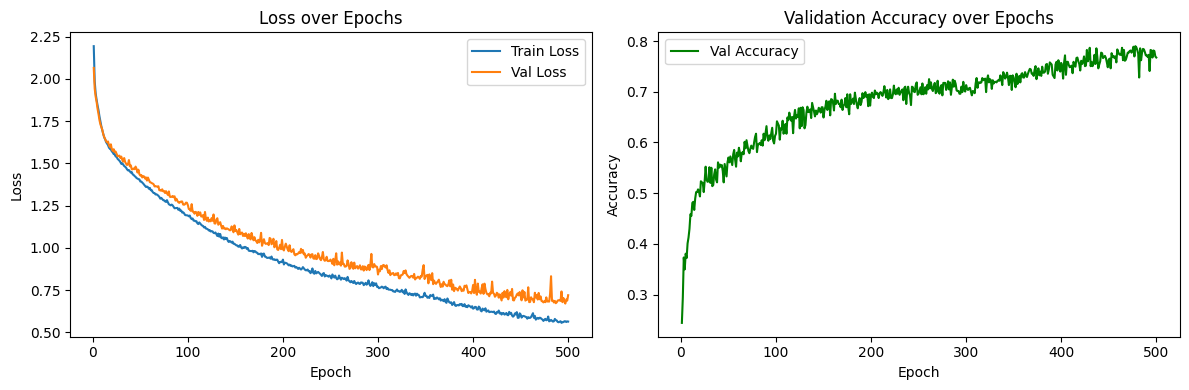

In [127]:
import matplotlib.pyplot as plt

epochs = range(1, 501)

plt.figure(figsize=(12, 4))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()


### Plot confusion matrix and get accuracy

In [128]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import os

def plot_confusion_matrix_gnn(model, data_loader, device, path_to_save, all_classes, dataset_name="val"):
    model.eval()
    y_true = []
    y_pred_classes = []

    with torch.no_grad():
        for data in data_loader:
            data = data.to(device)
            out = model(data)
            preds = out.argmax(dim=1).cpu().numpy()
            labels = data.y.cpu().numpy()

            y_pred_classes.extend(preds)
            y_true.extend(labels)
            
    # Compute metrics
    cm = confusion_matrix(y_true, y_pred_classes)
    acc = accuracy_score(y_true, y_pred_classes)
    prec = precision_score(y_true, y_pred_classes, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred_classes, average='macro', zero_division=0)

    # Plot
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=all_classes, yticklabels=all_classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f"{dataset_name.capitalize()} Confusion Matrix\n"
              f"Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")

    filename = f"{path_to_save}_{dataset_name}_confusion_matrix.png"
    if os.path.exists(filename):
        os.remove(filename)
    os.makedirs(os.path.dirname(path_to_save), exist_ok=True)
    plt.savefig(filename, bbox_inches='tight')
    print(f'[INFO] Saved confusion matrix for {dataset_name} set at {filename}')

[INFO] Saved confusion matrix for val set at output/gnn_val_confusion_matrix.png
[INFO] Saved confusion matrix for test set at output/gnn_test_confusion_matrix.png


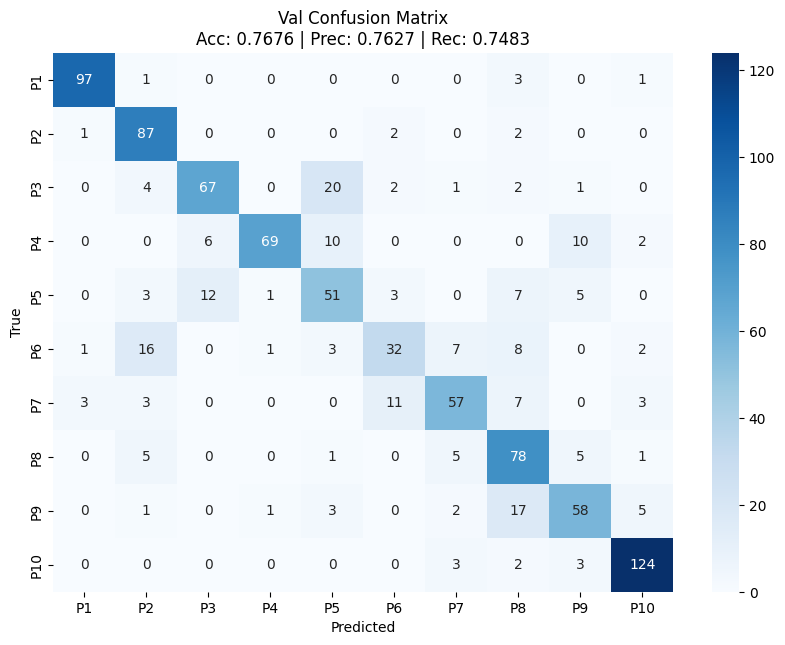

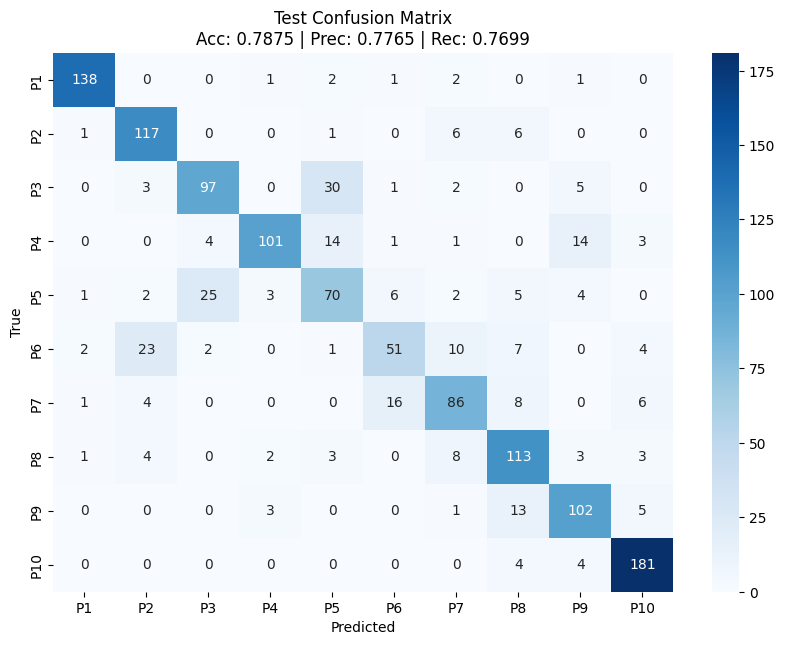

In [129]:
# Validation matrix
plot_confusion_matrix_gnn(
    model=model,
    data_loader=val_loader,
    device=device,
    path_to_save="output/gnn",
    all_classes=['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10'],
    dataset_name="val"
)

# Test matrix
plot_confusion_matrix_gnn(
    model=model,
    data_loader=test_loader,
    device=device,
    path_to_save="output/gnn",
    all_classes=['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10'],
    dataset_name="test"
)